# 08 - Model Evaluation and Explainability

Inspect saved model metrics, confusion matrices, SHAP outputs, and drift artifacts.

## 1. Setup

In [1]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image, HTML


def resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root. Run this notebook from the repo or notebooks folder.')

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config
from src.pipeline_reporting import configure_pretty_logging, output_dir, save_dataset_inventory, save_dataframe, save_table_image, save_bar_chart

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
paths = config['paths']
processed_dir = PROJECT_ROOT / paths.get('processed_data_dir', 'data/processed')
raw_dir = PROJECT_ROOT / paths.get('raw_data_dir', 'data/raw')
outputs_dir = PROJECT_ROOT / 'outputs'
notebook_out = output_dir('08_model_evaluation', root=outputs_dir / 'notebook_reports')
log_file = configure_pretty_logging(PROJECT_ROOT / 'logs', '08_model_evaluation')
print('Project root:', PROJECT_ROOT)
print('Notebook output dir:', notebook_out)
print('Notebook log file:', log_file)

Project root: C:\Code\flight-disruption-prediction
Notebook output dir: C:\Code\flight-disruption-prediction\outputs\notebook_reports\08_model_evaluation
Notebook log file: C:\Code\flight-disruption-prediction\logs\08_model_evaluation_20260420_173459.log


## 2. Artifact Inventory

In [2]:
artifacts = {
    'model_comparison_json': PROJECT_ROOT / 'logs' / 'model_comparison.json',
    'model_comparison_png': PROJECT_ROOT / 'outputs' / 'model_comparison.png',
    'roc_curves': PROJECT_ROOT / 'outputs' / 'roc_curves.png',
    'shap_summary': PROJECT_ROOT / 'outputs' / 'shap_summary.png',
    'xgboost_model': PROJECT_ROOT / 'models' / 'xgboost.pkl',
    'feature_importance': PROJECT_ROOT / 'models' / 'feature_importance.json',
}
artifact_df = pd.DataFrame([{'artifact': k, 'path': str(v), 'exists': v.exists(), 'size_mb': round(v.stat().st_size/1024**2, 3) if v.exists() else 0} for k,v in artifacts.items()])
save_dataframe(artifact_df, 'evaluation_artifact_inventory', notebook_out)
display(artifact_df)

,artifact,path,exists,size_mb
0,model_comparison_json,C:\Code\flight-disruption-prediction\logs\mode...,True,0.002
1,model_comparison_png,C:\Code\flight-disruption-prediction\outputs\m...,True,0.050
2,roc_curves,C:\Code\flight-disruption-prediction\outputs\r...,True,0.115
3,shap_summary,C:\Code\flight-disruption-prediction\outputs\s...,True,0.218
4,xgboost_model,C:\Code\flight-disruption-prediction\models\xg...,True,13.264
5,feature_importance,C:\Code\flight-disruption-prediction\models\fe...,True,0.002


## 3. Model Comparison

In [3]:
comparison_path = artifacts['model_comparison_json']
if comparison_path.exists():
    comparison = json.loads(comparison_path.read_text(encoding='utf-8'))
    ranking = pd.DataFrame(comparison.get('ranking', []))
    display(ranking)
    if not ranking.empty:
        save_dataframe(ranking, 'model_comparison_ranking', notebook_out)
else:
    print('Model comparison missing.')

,model,weighted_f1,macro_f1,cohens_kappa,pr_auc_macro,pr_auc_weighted,precision,recall,accuracy,per_class_metrics
0,xgboost,0.825654,0.740985,0.482197,None,None,0.823681,0.828214,0.828214,"{'Late': {'recall': 0.5676348547717842, 'preci..."
1,random_forest,0.768259,0.606329,0.257026,None,None,0.819846,0.816254,0.816254,"{'Late': {'recall': 0.19695712309820193, 'prec..."
2,logistic_regression,0.676474,0.591109,0.215952,None,None,0.748917,0.647277,0.647277,"{'Late': {'recall': 0.6334716459197787, 'preci..."


## 4. Visual Review


model_comparison.png


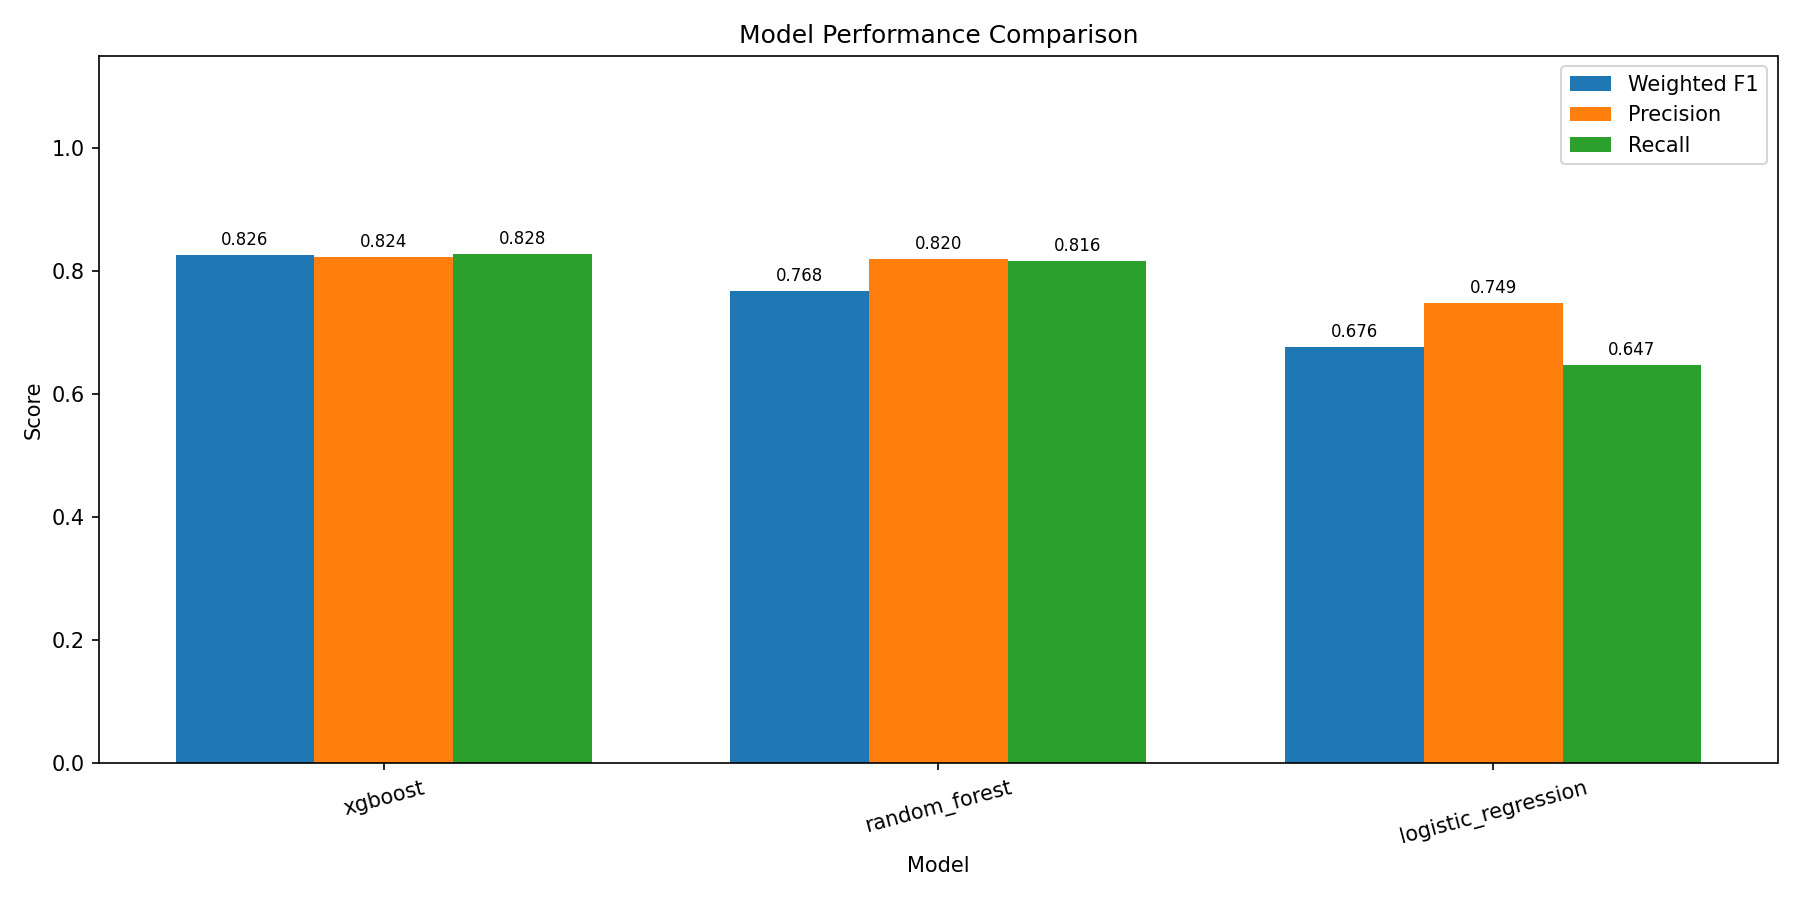


roc_curves.png


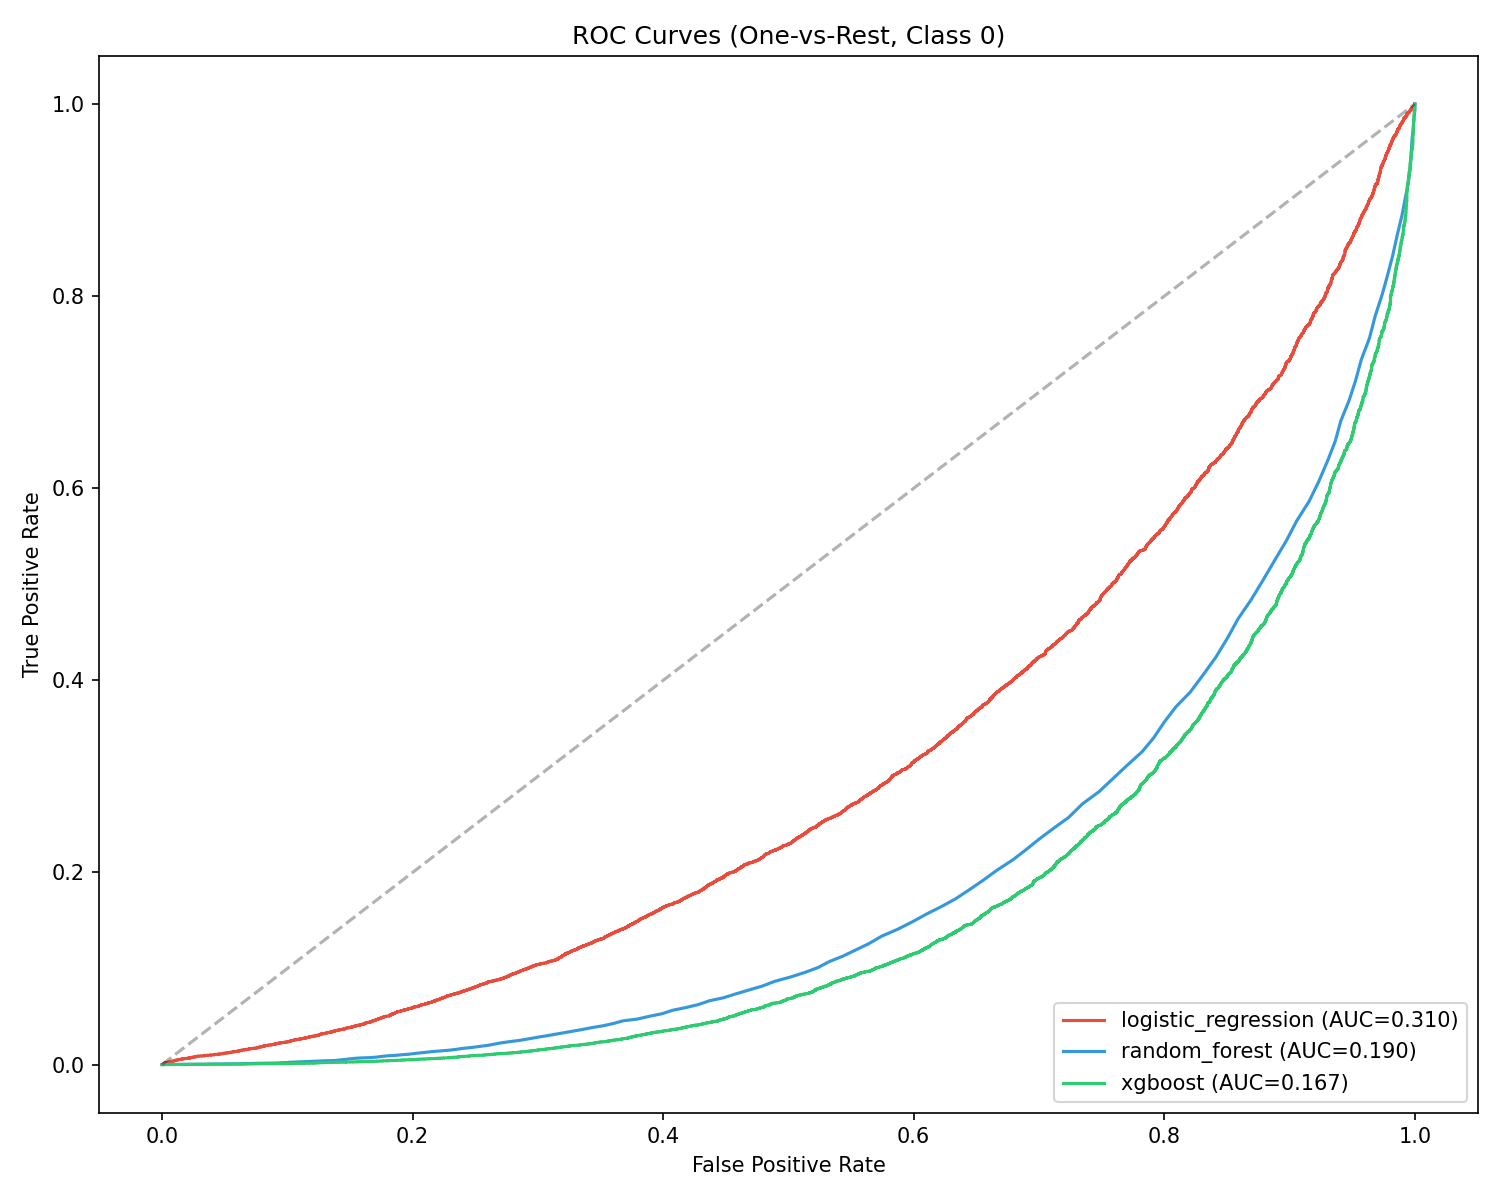


confusion_matrix_xgboost.png


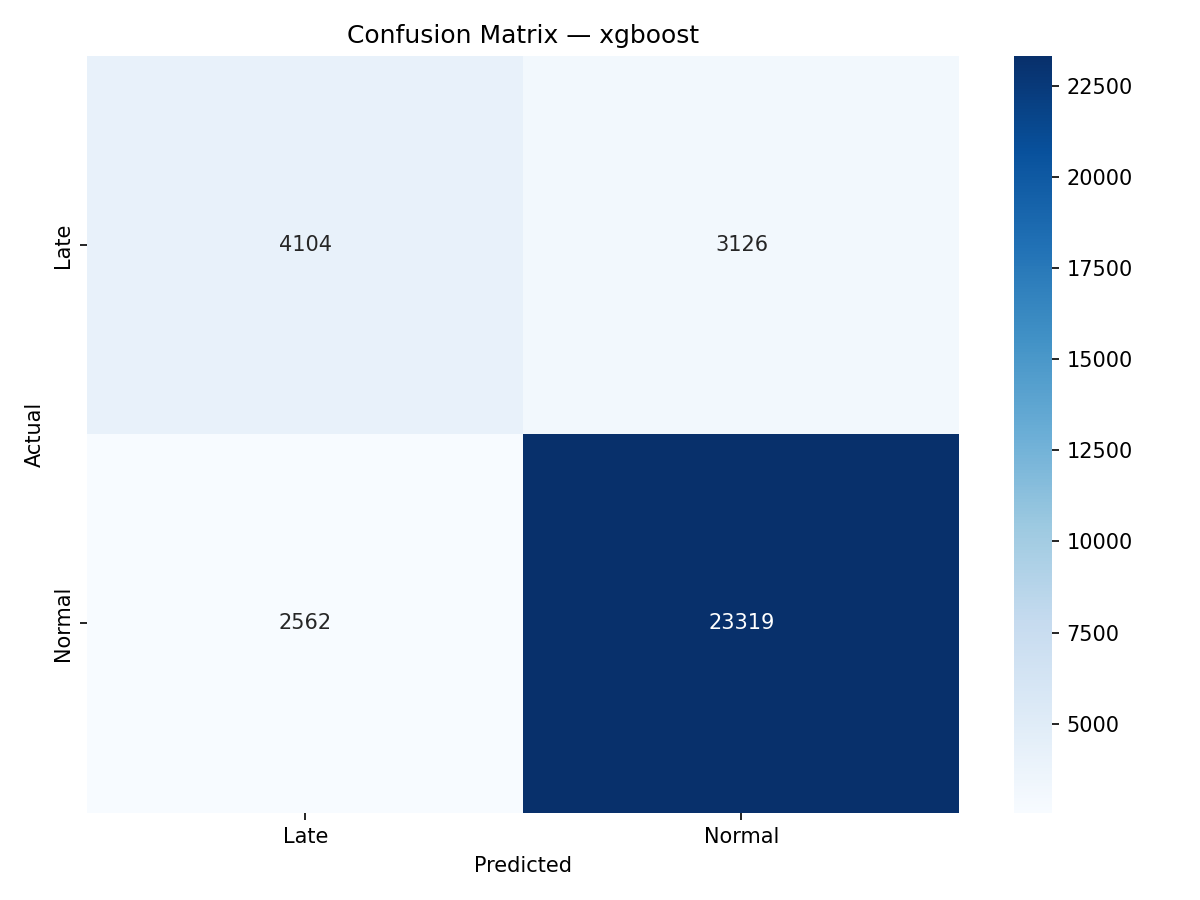


shap_summary.png


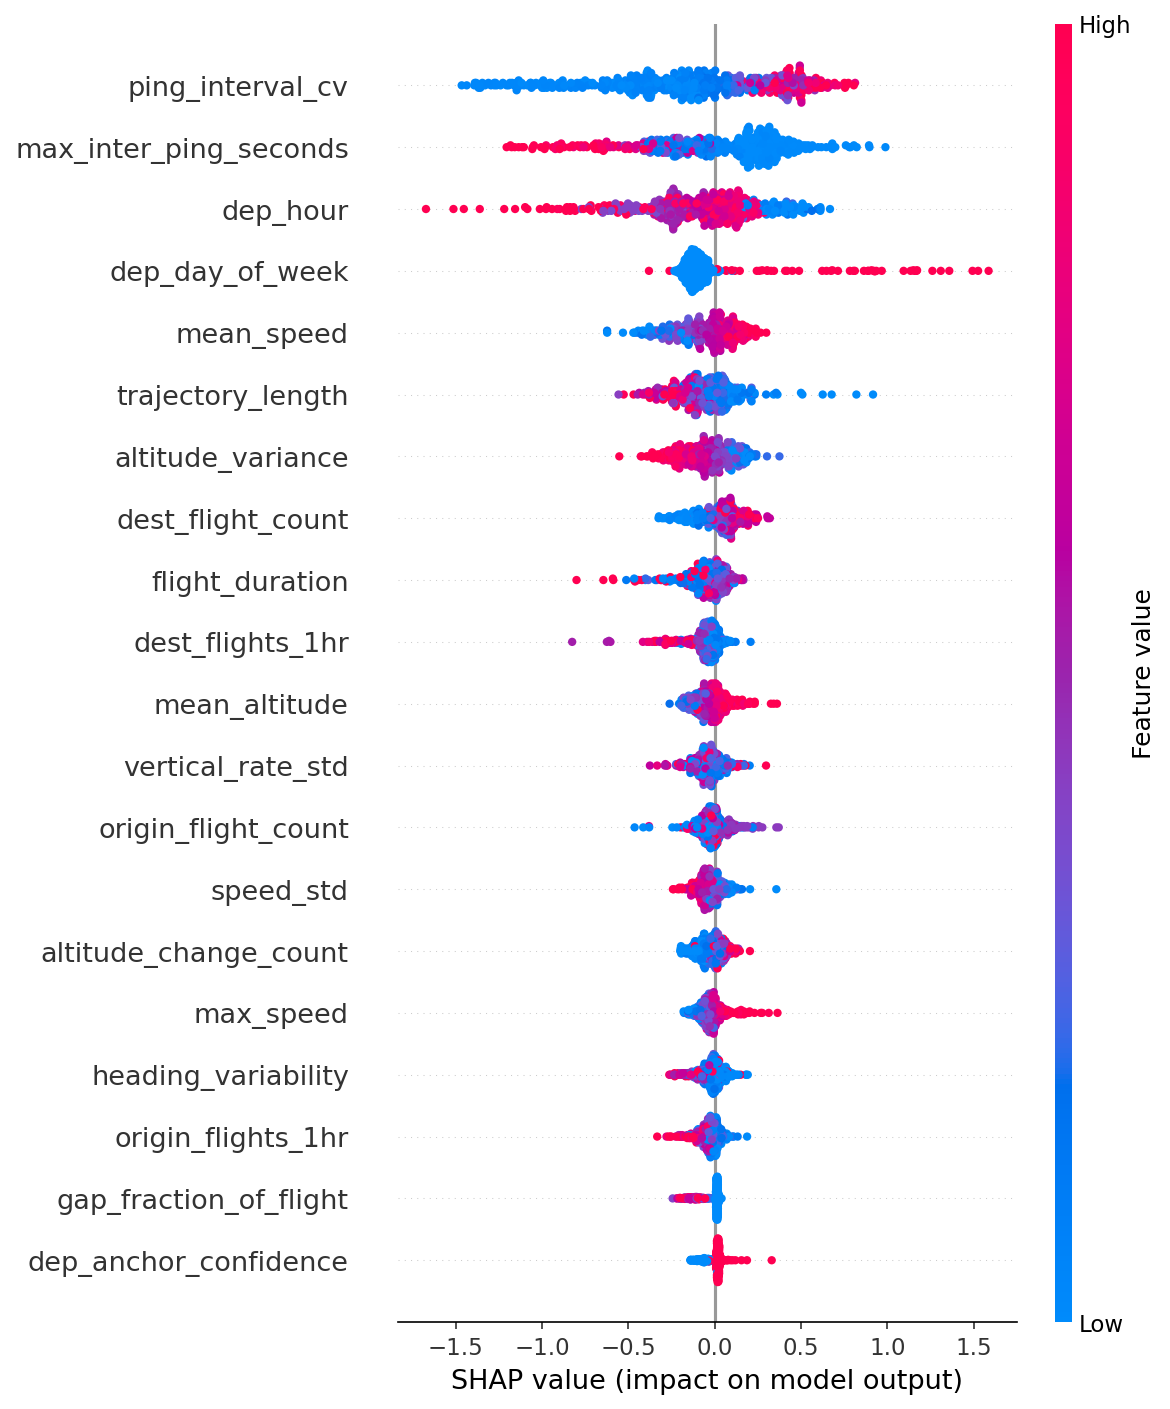

In [4]:
for image_name in ['model_comparison.png', 'roc_curves.png', 'confusion_matrix_xgboost.png', 'shap_summary.png']:
    image_path = PROJECT_ROOT / 'outputs' / image_name
    if image_path.exists():
        print('\n' + image_name)
        display(Image(filename=str(image_path)))
    else:
        print('Missing:', image_name)